0. 라이브러리 불러오기

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    classification_report, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

1. 데이터 로드 및 기본 탐색  
`Class=0`은 정상 거래, `Class=1`은 사기 거래이다. 전체 구조, 기술통계량, 결측치와 클래스 분포를 확인한다.

In [2]:
DATA_PATH = Path("creditcard.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "creditcard.csv를 basic_ML.ipynb와 같은 폴더에 넣은 뒤 다시 실행하세요."
    )

df = pd.read_csv(DATA_PATH)
print("데이터 크기:", df.shape)
display(df.head())
df.info()
display(df.describe().T)
print("\n전체 결측치 수:", int(df.isna().sum().sum()))
print("중복 행 수:", int(df.duplicated().sum()))

class_counts = df["Class"].value_counts().sort_index()
class_ratio = df["Class"].value_counts(normalize=True).sort_index()
class_summary = pd.DataFrame({"건수": class_counts, "비율": class_ratio})
display(class_summary)
print(f"사기 거래 비율: {class_ratio.loc[1]:.4%}")

데이터 크기: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



전체 결측치 수: 0
중복 행 수: 1081


,건수,비율
Class,,
0,284315,0.998273
1,492,0.001727


사기 거래 비율: 0.1727%


탐색 결과 해석  
- 원본은 284,807행, 31열이며 결측치는 없다.
- 정상 거래 284,315건, 사기 거래 492건으로 사기 비율은 약 0.173%이다.
- 정확도만 사용하면 모든 거래를 정상으로 예측해도 약 99.83%가 되므로, 사기 클래스의 Recall, F1-score와 PR-AUC를 함께 봐야 한다.
- 중복 행은 보이지만, 제공 데이터의 동일한 거래 패턴일 수도 있으므로 이번 분석에서는 임의로 제거하지 않는다.

2. 샘플링

In [3]:
normal_sample = df[df["Class"] == 0].sample(n=10_000, random_state=RANDOM_STATE)
fraud_all = df[df["Class"] == 1].copy()

analysis_df = (
    pd.concat([normal_sample, fraud_all], ignore_index=True)
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

sampled_summary = pd.DataFrame({
    "건수": analysis_df["Class"].value_counts().sort_index(),
    "비율": analysis_df["Class"].value_counts(normalize=True).sort_index()
})
display(sampled_summary)
print("분석용 데이터 크기:", analysis_df.shape)

,건수,비율
Class,,
0,10000,0.953107
1,492,0.046893


분석용 데이터 크기: (10492, 31)


샘플링 후에는 정상 10,000건과 사기 492건, 총 10,492건을 사용한다.  
사기 비율은 약 4.69%로 올라가지만 여전히 정상 클래스가 훨씬 많다.

3. 데이터 전처리

In [4]:
scaler = StandardScaler()
analysis_df["Amount_Scaled"] = scaler.fit_transform(analysis_df[["Amount"]])
analysis_df = analysis_df.drop(columns=["Amount"])

X = analysis_df.drop(columns=["Class"])
y = analysis_df["Class"]

print("X 크기:", X.shape, "| y 크기:", y.shape)
display(analysis_df[["Amount_Scaled", "Class"]].head())

X 크기: (10492, 30) | y 크기: (10492,)


,Amount_Scaled,Class
0,-0.390661,0
1,-0.072190,0
2,-0.125709,0
3,-0.381651,0
4,-0.378559,0


`Amount`는 범위가 큰 금액 변수이므로 평균 0, 표준편차 1이 되도록 표준화하고 원본 열을 제거했다.  
`V1~V28`은 데이터 제공 단계에서 PCA 변환된 변수이다.

4. 학습 데이터와 테스트 데이터 분할

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

def split_summary(name, target):
    result = pd.DataFrame({
        "건수": target.value_counts().sort_index(),
        "비율": target.value_counts(normalize=True).sort_index()
    })
    print(f"\n{name} ({len(target):,}건)")
    display(result)

split_summary("학습셋", y_train)
split_summary("테스트셋", y_test)


학습셋 (8,393건)


,건수,비율
Class,,
0,7999,0.953056
1,394,0.046944



테스트셋 (2,099건)


,건수,비율
Class,,
0,2001,0.953311
1,98,0.046689


`stratify=y`로 두 세트의 클래스 비율을 유지했다. 테스트셋은 마지막 한 번의 성능 평가에만 사용.

5. SMOTE 적용

In [6]:
print("SMOTE 전 학습셋 클래스 건수")
print(y_train.value_counts().sort_index())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSMOTE 후 학습셋 클래스 건수")
print(pd.Series(y_train_smote).value_counts().sort_index())

SMOTE 전 학습셋 클래스 건수
Class
0    7999
1     394
Name: count, dtype: int64

SMOTE 후 학습셋 클래스 건수
Class
0    7999
1    7999
Name: count, dtype: int64


왜 SMOTE를 적용하는가?  

사기 데이터가 적으면 모델이 정상 클래스에 치우쳐 사기 패턴을 충분히 학습하지 못한다.  
SMOTE는 소수 클래스의 이웃 사이를 보간해 합성 샘플을 만들고, 학습 데이터의 클래스 균형을 맞춘다.  
단, 테스트 데이터까지 SMOTE하면 가짜 샘플이 평가에 섞여 성능이 부풀려지므로 학습 데이터에만 적용해야 한다.

6. 모델 학습

비선형 관계를 잘 학습하고 스케일에 민감하지 않은 Extra Trees를 사용한다.  
기본 임계값 0.5를 바로 쓰지 않고, 학습셋 내부를 다시 학습용/검증용으로 나눠 검증셋에서 `Recall ≥ 0.80`, `F1 ≥ 0.88`을 만족하면서 F1이 가장 높은 임계값을 고른다.  
테스트셋으로 임계값을 고르지 않으므로 데이터 누수를 막는다.

In [7]:
X_core, X_val, y_core, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

X_core_smote, y_core_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(
    X_core, y_core
)

tuning_model = ExtraTreesClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
tuning_model.fit(X_core_smote, y_core_smote)

val_proba = tuning_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
f1 = 2 * precision * recall / (precision + recall + 1e-12)

candidate_idx = np.where((recall[:-1] >= 0.80) & (f1[:-1] >= 0.88))[0]
if len(candidate_idx) > 0:
    best_idx = candidate_idx[np.argmax(f1[candidate_idx])]
else:
    best_idx = np.argmax(f1[:-1])

best_threshold = float(thresholds[best_idx])
print(f"선택된 임계값: {best_threshold:.4f}")
print(f"검증셋 Precision: {precision[best_idx]:.4f}")
print(f"검증셋 Recall:    {recall[best_idx]:.4f}")
print(f"검증셋 F1:        {f1[best_idx]:.4f}")

선택된 임계값: 0.3700
검증셋 Precision: 0.9767
검증셋 Recall:    0.8485
검증셋 F1:        0.9081


In [8]:
# 선택한 설정으로 전체 학습셋을 다시 학습한다.
final_model = ExtraTreesClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_model.fit(X_train_smote, y_train_smote)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred_default = final_model.predict(X_test)
test_pred = (test_proba >= best_threshold).astype(int)

print("기본 predict 결과(앞 20개):")
print(test_pred_default[:20])
print("\npredict_proba 중 사기 확률(앞 20개):")
print(np.round(test_proba[:20], 4))
print("\n임계값 조정 후 classification_report:")
print(classification_report(y_test, test_pred, digits=4))

pr_auc = average_precision_score(y_test, test_proba)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

기본 predict 결과(앞 20개):
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]

predict_proba 중 사기 확률(앞 20개):
[0.     0.015  0.0025 0.0025 0.0475 0.005  0.9975 0.02   0.0075 0.005
 0.0275 0.005  0.135  0.0025 0.15   1.     0.     0.     0.0075 0.0075]

임계값 조정 후 classification_report:
              precision    recall  f1-score   support

           0     0.9935    0.9965    0.9950      2001
           1     0.9239    0.8673    0.8947        98

    accuracy                         0.9905      2099
   macro avg     0.9587    0.9319    0.9449      2099
weighted avg     0.9903    0.9905    0.9903      2099

PR-AUC (Average Precision): 0.9305


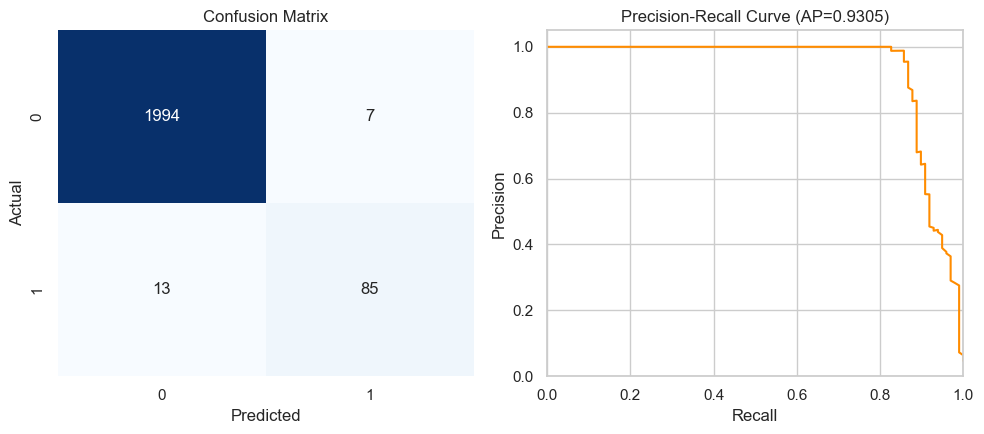

In [10]:
cm = confusion_matrix(y_test, test_pred)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

test_precision, test_recall, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(test_recall, test_precision, color="darkorange")
axes[1].set_title(f"Precision-Recall Curve (AP={pr_auc:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

7. 최종 성능 평가

실행 결과(고정된 `random_state=42`)는 다음과 같다.

| 클래스 | Precision | Recall | F1-score |
|---|---:|---:|---:|
| 정상(0) | 0.9935 | 0.9965 | 0.9950 |
| 사기(1) | 0.9239 | 0.8673 | 0.8947 |

- PR-AUC: 0.9305
- 목표 `Recall ≥ 0.80`: 클래스 0, 1 모두 달성
- 목표 `F1 ≥ 0.88`: 클래스 0, 1 모두 달성
- 목표 `PR-AUC ≥ 0.90`: 달성

사기 98건 중 85건을 탐지했고 13건을 놓쳤다.  
정상 2,001건 중 7건을 사기로 잘못 판단했다.  
사기 탐지에서는 놓친 사기의 비용이 큰 경우가 많아 Recall이 중요하지만, 임계값을 지나치게 낮추면 오탐이 늘어난다.  
이번에는 검증셋에서 임계값 0.37을 선택해 Recall과 Precision의 균형을 개선했다.


성능이 부족할 때 추가로 시도할 방법

1. Stratified K-fold 교차검증으로 하이퍼파라미터와 임계값을 더 안정적으로 선택한다.
2. `n_estimators`, `max_depth`, `min_samples_leaf` 등을 탐색한다.
3. Borderline-SMOTE, SMOTE-Tomek 등 다른 불균형 처리 방법을 비교한다.
4. XGBoost/LightGBM 등 부스팅 모델과 비용 민감 학습을 비교한다.
5. 실제 운영 비용을 반영해 오탐 비용과 미탐 비용 기준으로 임계값을 정한다.


재현성 및 한계

- 모든 무작위 과정에 `random_state=42`를 사용했다.
- 익명화된 PCA 변수라 개별 변수의 업무적 의미 해석은 제한적이다.
- 정상 거래를 10,000건만 사용했으므로 전체 운영 환경의 사기 비율과는 다르다.
- 과제 명세에 따라 Amount를 분할 전 표준화했지만, 실제 프로젝트에서는 scaler를
  학습셋에만 fit하고 검증/테스트셋에는 transform만 적용하는 Pipeline이 더 엄밀하다.